### **TD3 LUNAR LANDER CONTINUOUS TORCH**

TD3, short for **Twin Delayed Deep Deterministic Policy Gradient**, is an off-policy actor-critic algorithm for **continuous action spaces**. This notebook uses `LunarLanderContinuous-v3`, where the policy does not choose among discrete engine commands. Instead, it outputs two real-valued controls:

- **Main engine throttle**: continuous value in the action range.
- **Side engine throttle**: continuous value in the action range.

**Why TD3 instead of DQN or REINFORCE here:**

- **DQN** is designed for discrete actions, so it is not a natural fit for continuous control.
- **REINFORCE** can handle stochastic policies, but it is high-variance and usually slow on LunarLander.
- **TD3** learns a deterministic actor and two critics from a replay buffer, which makes it much more sample-efficient for continuous control.

**TD3 in one sentence:** learn two Q-functions, use the smaller target value to reduce overestimation, update the actor less often than the critics, and add small noise to target actions so the critic learns smoother values.


In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import time
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))


Using device: cuda
NVIDIA GB10


#### **Hyperparameters**

LunarLander continuous control is harder than the discrete version because the policy must learn **how much** thrust to apply, not only **which** engine command to select.

The settings below are intentionally conservative and readable:

- `START_TIMESTEPS`: collect random experience first, so the replay buffer is not empty and narrow.
- `EXPL_NOISE`: Gaussian noise added to the actor during training for exploration.
- `POLICY_NOISE` and `NOISE_CLIP`: TD3 target-policy smoothing.
- `POLICY_FREQ`: delayed actor updates; critics update every training step, actor updates every 2 critic updates.
- `ROLLING_WINDOW`: continuous LunarLander is considered solved around mean reward >= 200.


In [3]:
EPISODES = 1_000
MAX_EPISODES = EPISODES
MAX_STEPS_PER_EPISODE = 1_000

BUFFER_SIZE = 1_000_000
BATCH_SIZE = 256
START_TIMESTEPS = 10_000

DISCOUNT = 0.99
TAU = 0.005
ACTOR_LR = 3e-4
CRITIC_LR = 3e-4

EXPL_NOISE = 0.10
POLICY_NOISE = 0.20
NOISE_CLIP = 0.50
POLICY_FREQ = 2

ROLLING_WINDOW = 100
solved_threshold = 200

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


#### **TD3 Agent**

TD3 has three moving parts:

1. **Replay buffer**: stores transitions `(state, action, reward, next_state, not_done)` so the agent can train from many past experiences.
2. **Actor**: maps a state to one continuous action vector.
3. **Twin critics**: estimate `Q(state, action)` twice. TD3 uses the smaller estimate when building the target, which helps control optimistic Q-value errors.

The code below keeps the implementation close to the algorithm. There are classes because the actor, critic, replay buffer, and agent have state, but the methods are intentionally short.


In [4]:
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=BUFFER_SIZE):
        self.max_size = int(max_size)
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((self.max_size, state_dim), dtype=np.float32)
        self.actions = np.zeros((self.max_size, action_dim), dtype=np.float32)
        self.rewards = np.zeros((self.max_size, 1), dtype=np.float32)
        self.next_states = np.zeros((self.max_size, state_dim), dtype=np.float32)
        self.not_dones = np.zeros((self.max_size, 1), dtype=np.float32)

    def add(self, state, action, reward, next_state, not_done):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.not_dones[self.ptr] = not_done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        ind = np.random.randint(0, self.size, size=batch_size)

        states = torch.tensor(self.states[ind], device=device)
        actions = torch.tensor(self.actions[ind], device=device)
        rewards = torch.tensor(self.rewards[ind], device=device)
        next_states = torch.tensor(self.next_states[ind], device=device)
        not_dones = torch.tensor(self.not_dones[ind], device=device)
        return states, actions, rewards, next_states, not_dones


class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.max_action = torch.tensor(max_action, dtype=torch.float32, device=device)
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, action_dim), nn.Tanh(),
        )

    def forward(self, state):
        return self.net(state) * self.max_action


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1),
        )
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa), self.q2(sa)

    def q1_value(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa)


class TD3Agent:
    def __init__(self, state_dim, action_dim, max_action):
        self.max_action = max_action
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=ACTOR_LR)

        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=CRITIC_LR)

        self.total_it = 0

    def select_action(self, state):
        state = torch.tensor(state.reshape(1, -1), dtype=torch.float32, device=device)
        action = self.actor(state).cpu().data.numpy().flatten()
        return action

    def train(self, replay_buffer, batch_size=BATCH_SIZE):
        self.total_it += 1
        states, actions, rewards, next_states, not_dones = replay_buffer.sample(batch_size)

        with torch.no_grad():
            noise = torch.randn_like(actions) * POLICY_NOISE
            noise = noise.clamp(-NOISE_CLIP, NOISE_CLIP)

            next_actions = self.actor_target(next_states) + noise
            max_action = torch.tensor(self.max_action, dtype=torch.float32, device=device)
            next_actions = torch.max(torch.min(next_actions, max_action), -max_action)

            target_q1, target_q2 = self.critic_target(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2)
            target_q = rewards + not_dones * DISCOUNT * target_q

        current_q1, current_q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(current_q1, target_q) + F.mse_loss(current_q2, target_q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss_value = None
        if self.total_it % POLICY_FREQ == 0:
            actor_loss = -self.critic.q1_value(states, self.actor(states)).mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            actor_loss_value = actor_loss.item()

            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        return critic_loss.item(), actor_loss_value


#### **Training loop**

The loop has two phases:

1. **Warm-up exploration**: before `START_TIMESTEPS`, actions are sampled randomly from the environment.
2. **TD3 training**: after warm-up, the actor chooses an action and we add clipped Gaussian exploration noise.

One important bookkeeping detail: if an episode ends only because of the time limit, we usually still bootstrap the critic target. If the lander actually crashes or lands, `terminated=True`, so the target should stop there.


In [5]:
start_time = time.time()

env = gym.make('LunarLanderContinuous-v3')
env.action_space.seed(SEED)
state, _ = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = env.action_space.high.astype(np.float32)

agent = TD3Agent(state_dim, action_dim, max_action)
replay_buffer = ReplayBuffer(state_dim, action_dim)

scores, episodes, rolling_avg_rewards = [], [], []
critic_losses, actor_losses = [], []
total_steps = 0

for e in range(MAX_EPISODES):
    state, _ = env.reset()
    episode_reward = 0.0
    episode_critic_losses, episode_actor_losses = [], []

    for step in range(MAX_STEPS_PER_EPISODE):
        total_steps += 1

        if total_steps < START_TIMESTEPS:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)
            noise = np.random.normal(0, max_action * EXPL_NOISE, size=action_dim)
            action = np.clip(action + noise, env.action_space.low, env.action_space.high)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        not_done = 0.0 if terminated else 1.0

        replay_buffer.add(state, action, reward, next_state, not_done)
        state = next_state
        episode_reward += reward

        if replay_buffer.size >= BATCH_SIZE and total_steps >= START_TIMESTEPS:
            critic_loss, actor_loss = agent.train(replay_buffer)
            episode_critic_losses.append(critic_loss)
            if actor_loss is not None:
                episode_actor_losses.append(actor_loss)

        if done:
            break

    scores.append(episode_reward)
    episodes.append(e + 1)
    rolling_avg = np.mean(scores[-ROLLING_WINDOW:])
    rolling_avg_rewards.append(rolling_avg)

    if episode_critic_losses:
        critic_losses.append(np.mean(episode_critic_losses))
    else:
        critic_losses.append(np.nan)

    if episode_actor_losses:
        actor_losses.append(np.mean(episode_actor_losses))
    else:
        actor_losses.append(np.nan)

    print(f"Episode: {e+1:4d}/{MAX_EPISODES}  Reward: {episode_reward:+8.2f}  "
          f"Rolling{ROLLING_WINDOW}: {rolling_avg:+8.2f}  Steps: {step+1:4d}  "
          f"Total steps: {total_steps:7d}  Buffer: {replay_buffer.size:7d}")

    if len(scores) >= ROLLING_WINDOW and rolling_avg >= solved_threshold:
        print(f"\nSolved at episode {e+1}! Rolling{ROLLING_WINDOW} = {rolling_avg:.2f}")
        break

env.close()
elapsed_min = (time.time() - start_time) / 60
print(f"\nTraining completed in {elapsed_min:.2f} minutes")


/home/jaume/_DEVELOPMENT/ML/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode:    1/1000  Reward:  -265.80  Rolling100:  -265.80  Steps:  129  Total steps:     129  Buffer:     129
Episode:    2/1000  Reward:  -161.33  Rolling100:  -213.56  Steps:  108  Total steps:     237  Buffer:     237
Episode:    3/1000  Reward:  -226.41  Rolling100:  -217.85  Steps:   88  Total steps:     325  Buffer:     325
Episode:    4/1000  Reward:   -84.42  Rolling100:  -184.49  Steps:   68  Total steps:     393  Buffer:     393
Episode:    5/1000  Reward:   -95.98  Rolling100:  -166.79  Steps:  124  Total steps:     517  Buffer:     517
Episode:    6/1000  Reward:  -347.31  Rolling100:  -196.87  Steps:  113  Total steps:     630  Buffer:     630
Episode:    7/1000  Reward:  -348.89  Rolling100:  -218.59  Steps:   74  Total steps:     704  Buffer:     704
Episode:    8/1000  Reward:   -43.99  Rolling100:  -196.77  Steps:  101  Total steps:     805  Buffer:     805
Episode:    9/1000  Reward:  -263.29  Rolling100:  -204.16  Steps:   89  Total steps:     894  Buffer:     894
E

#### **Training curve visualization**

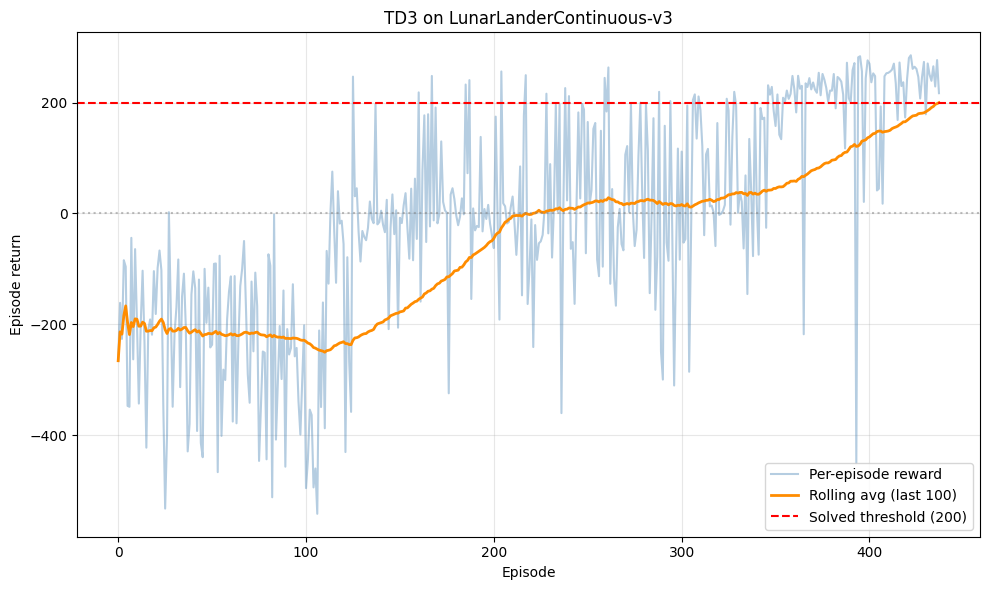

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(scores, color='steelblue', alpha=0.4, label='Per-episode reward')
plt.plot(rolling_avg_rewards, color='darkorange', linewidth=2,
         label=f'Rolling avg (last {ROLLING_WINDOW})')
plt.axhline(y=solved_threshold, color='red', linestyle='--',
            label=f'Solved threshold ({solved_threshold})')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.title('TD3 on LunarLanderContinuous-v3')
plt.xlabel('Episode')
plt.ylabel('Episode return')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


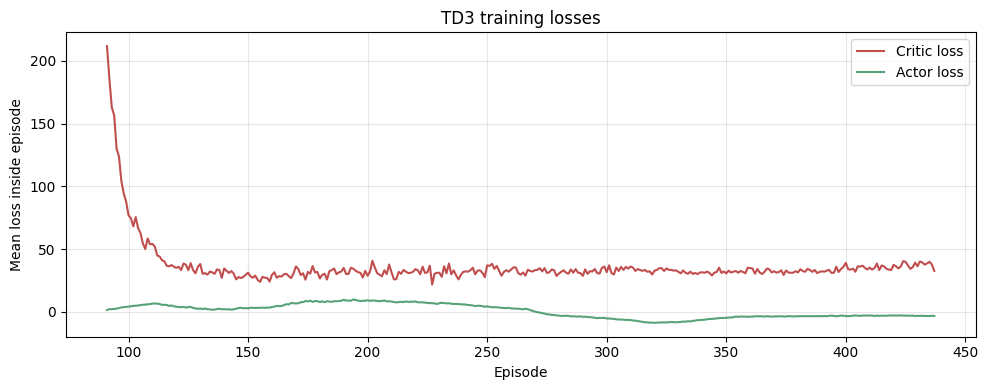

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(critic_losses, color='firebrick', alpha=0.8, label='Critic loss')
plt.plot(actor_losses, color='seagreen', alpha=0.8, label='Actor loss')
plt.title('TD3 training losses')
plt.xlabel('Episode')
plt.ylabel('Mean loss inside episode')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### **Evaluation Run 10 episodes**

Evaluation uses the actor directly, without exploration noise. TD3 learns a deterministic policy, so evaluation is usually less noisy than training.


In [8]:
env = gym.make('LunarLanderContinuous-v3')
test_rewards = []

for e_test in range(10):
    state, _ = env.reset()
    total_reward = 0.0

    for step in range(MAX_STEPS_PER_EPISODE):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    test_rewards.append(total_reward)
    print(f"Test episode {e_test+1:2d}/10  Reward: {total_reward:+8.2f}  Steps: {step+1}")

env.close()
print(f"\nMean test reward: {np.mean(test_rewards):+.2f}  (std {np.std(test_rewards):.2f})")


Test episode  1/10  Reward:  +232.70  Steps: 281
Test episode  2/10  Reward:  +261.80  Steps: 194
Test episode  3/10  Reward:  +255.79  Steps: 239
Test episode  4/10  Reward:  +266.86  Steps: 236
Test episode  5/10  Reward:  +169.75  Steps: 644
Test episode  6/10  Reward:  +273.82  Steps: 201
Test episode  7/10  Reward:  +275.28  Steps: 212
Test episode  8/10  Reward:  +279.82  Steps: 179
Test episode  9/10  Reward:  +240.28  Steps: 345
Test episode 10/10  Reward:  +247.55  Steps: 195

Mean test reward: +250.36  (std 30.64)


#### **Render an episode as a GIF**

In [9]:
env = gym.make('LunarLanderContinuous-v3', render_mode='rgb_array')
frames = []

state, _ = env.reset()
tot_rewards = 0.0

for step in range(MAX_STEPS_PER_EPISODE):
    action = agent.select_action(state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    tot_rewards += reward
    state = next_state

    if terminated or truncated:
        print(f"Episode reward: {tot_rewards:+.2f}  Steps: {step+1}")
        break

env.close()


def save_frames_as_gif(frames, path='./', filename='LunarLander_TD3_TORCH.gif'):
    images = [Image.fromarray(f) for f in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:],
                   duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")


save_frames_as_gif(frames)


Episode reward: +254.78  Steps: 216
Saved GIF to: ./LunarLander_TD3_TORCH.gif


#### **Notes on this implementation & next steps**

**Why TD3 is a strong fit here.** LunarLander continuous has low-dimensional observations and two continuous actions, so a deterministic actor plus replay-buffer training works well. The twin critics help avoid overestimating action values, and delayed actor updates keep the policy from chasing critic noise too aggressively.

**What to watch during training:**

- Early rewards can be very poor because the random warm-up may crash often.
- A rising rolling average matters more than a single great episode.
- Critic loss is not expected to go smoothly to zero; it tracks a moving target because the policy and target networks keep changing.

**Things to try if you want to improve it:**

- Increase `EPISODES` if the rolling average is still climbing.
- Tune `EXPL_NOISE`; too little exploration can get stuck, too much can prevent stable landings.
- Try smaller actor/critic networks for faster experiments, or larger ones if learning plateaus.
- Compare this with SAC, which often handles continuous control exploration more gracefully.


In [10]:
import session_info
session_info.show(html=False)

-----
PIL                 12.1.0
gymnasium           1.2.2
matplotlib          3.10.8
numpy               2.4.2
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1018-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-05-22 11:08
